## Name: Dillon Kamin
## Midterm Assessment
## DATA 581 -- Summer 2026

# Executive Summary

The purpose of the following analysis is in the task of identifying 3 penguin species across 3 separate islands in the Antarctica's Palmer Archipelago. The analysis was done by examining the amount of each species of penguin on each of the islands, then looking at physical traits of the penguins. Traits examined were the body mass, length of flippers, length of the bill, and depth of the bill.

* Species: Adelie, Chinstrap, and Gentoo
* Islands: Biscoe, Dream, and Torgersen

A few key insights resulted from the analysis:

1. Torgensen island has only Adelie penguins. Biscoe island has Adelie and Gentoo. Dream island has Adelie and Chinstrap.
2. Gentoo penguins are larger than the other two species, with bigger bodies and longer flippers.
3. Adelie penguins have shorter bill lengths than the other two species.

With these insights and for the task of identification, there are a few easy steps to identification that anyone can follow! First, think about what island the penguin is on: if it's Torgensen, then the penguin is an Adelie. If it's a different island or the island is unknown, look at the physical characteristics. Is the penguin quite large with long flippers? Then it's likely a Gentoo. If the penguin is on the smaller side but similar to others on the island, look at the bill. If the bill is on the shorter side, then that penguin is likely an Adelie. Otherwise, it's likely a Chinstrap.

# EDA

* First want to load the dataset and clean up any places that are missing values.
* Since only 11 of the 344 rows are missing any data, we can pretty safely drop those rows
* With the cleaned version of the dataset, we can then summarize columns with some statistics about each

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset("penguins")
print(penguins.columns)

print("Dataset length:", len(penguins))

nans = penguins[penguins.isna().any(axis=1)]
print("Rows with missing data:", len(nans))
# print(nans)

penguins_cleaned = penguins.dropna()

print(penguins_cleaned.describe())
print(penguins_cleaned.describe(include=['object']))

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')
Dataset length: 344
Rows with missing data: 11
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000
       species  island   sex
count      333     333   333
unique       3       3     2
top     Adelie  Biscoe  Male
freq       146     163   168


## Categorical comparisons (species, island, and sex)

The following visualizations reveal:

* The distribution of male and female is equal by species and island.
* The Adelie species is found on all three islands, but Chinstrap and Gentoo are only found on Dream and Biscoe, respectively.
  

<function matplotlib.pyplot.show(close=None, block=None)>

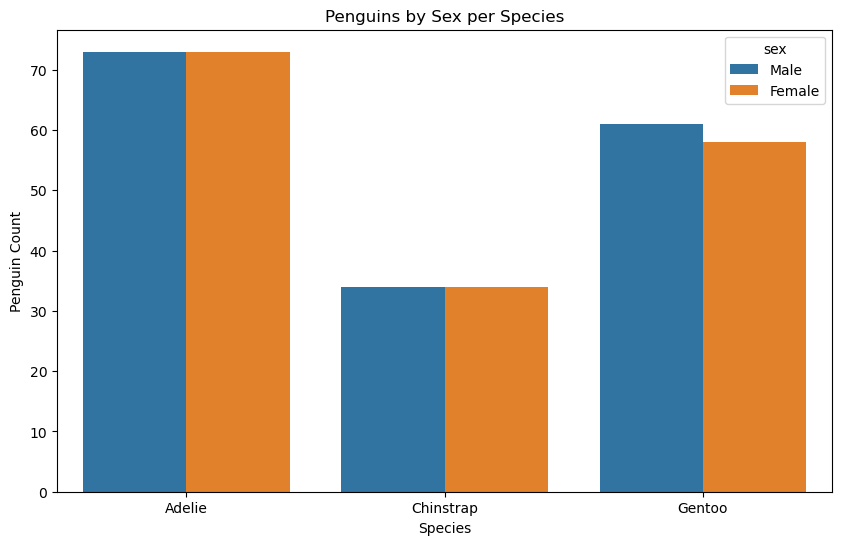

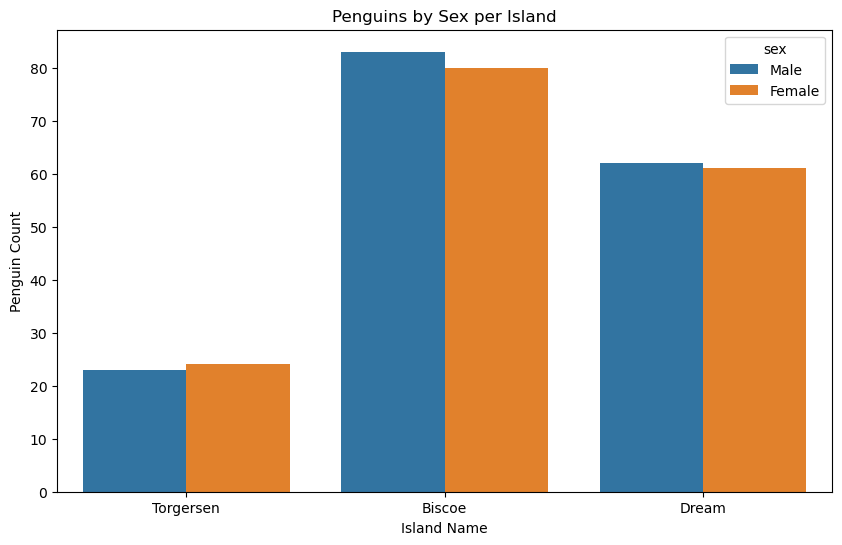

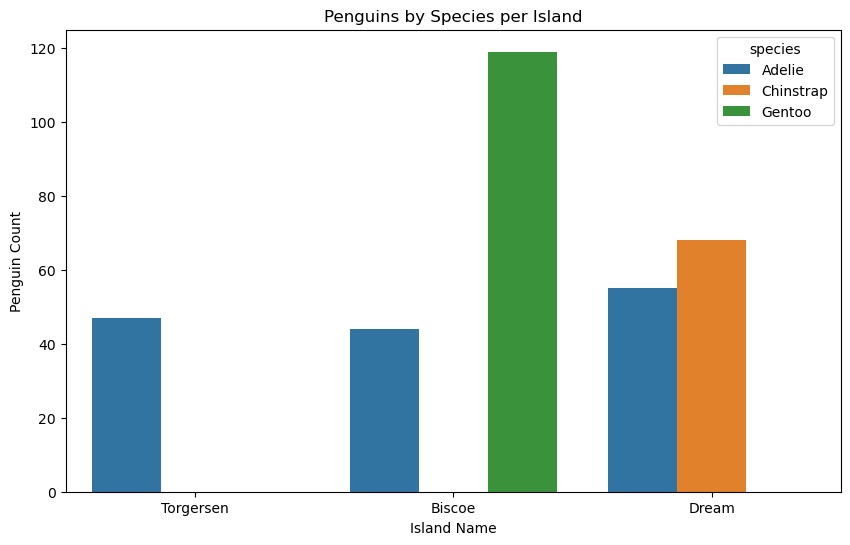

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(data=penguins_cleaned, x='species', hue='sex')
plt.title("Penguins by Sex per Species")
plt.xlabel("Species")
plt.ylabel("Penguin Count")

plt.figure(figsize=(10,6))
sns.countplot(data=penguins_cleaned, x='island', hue='sex')
plt.title("Penguins by Sex per Island")
plt.xlabel("Island Name")
plt.ylabel("Penguin Count")

plt.figure(figsize=(10,6))
sns.countplot(data=penguins_cleaned, x='island', hue='species')
plt.title("Penguins by Species per Island")
plt.xlabel("Island Name")
plt.ylabel("Penguin Count")
plt.show

## Distribution charts (body mass, flipper length, bill length)

The following visualizations reveal:

* Sexual dimorphism in body mass, flipper length, and bill characteristics. Males consistently have larger or heavier features than females do.
* The Gentoo species is in general the largest in mass and flipper length. Though its bill length is similar to the Chinstrap species. Whereas the Chinstrap and Adelie are similar in mass and flipper length. Bill depth for the Gentoo is the smallest, while the other two species are similar.
  

<function matplotlib.pyplot.show(close=None, block=None)>

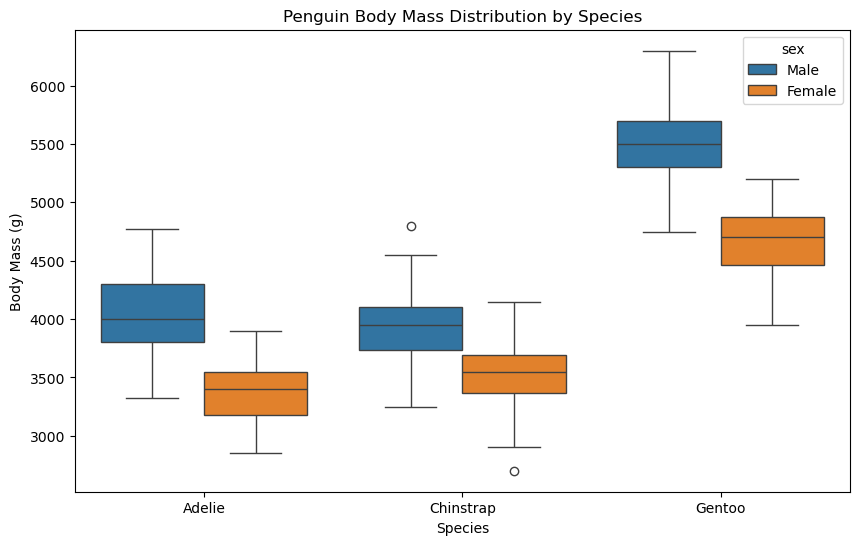

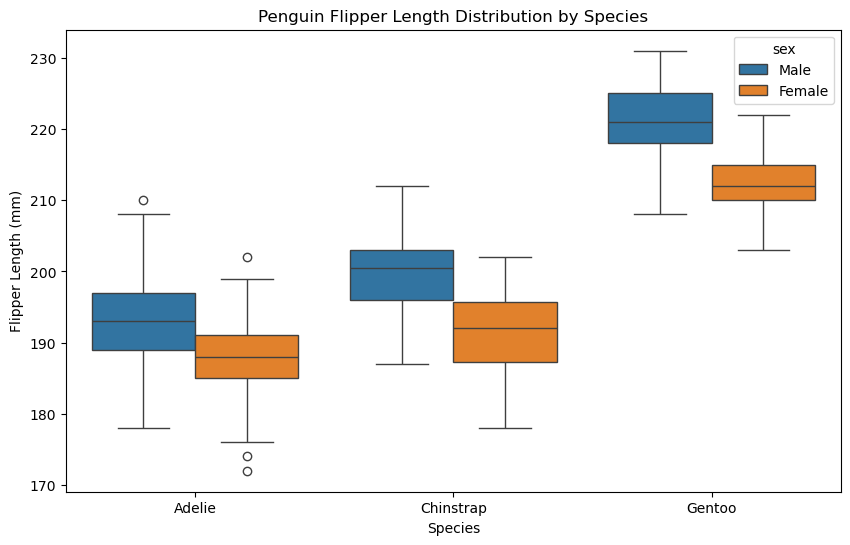

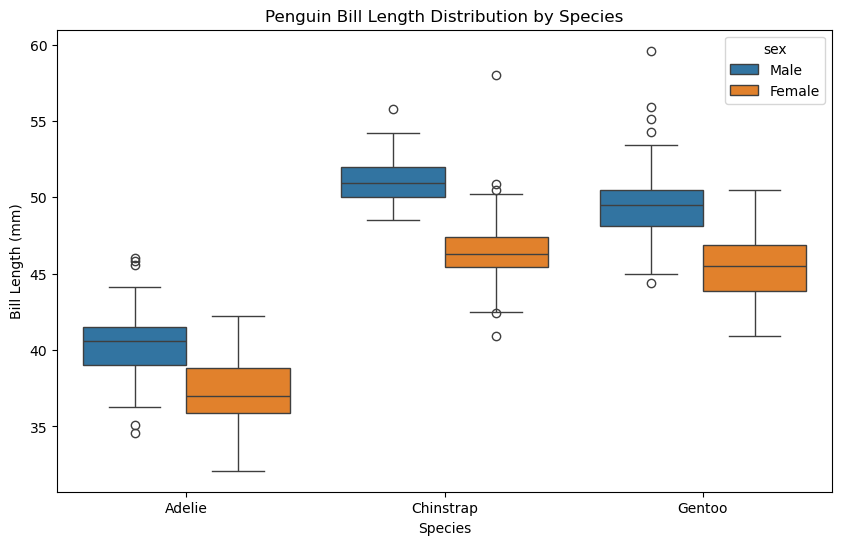

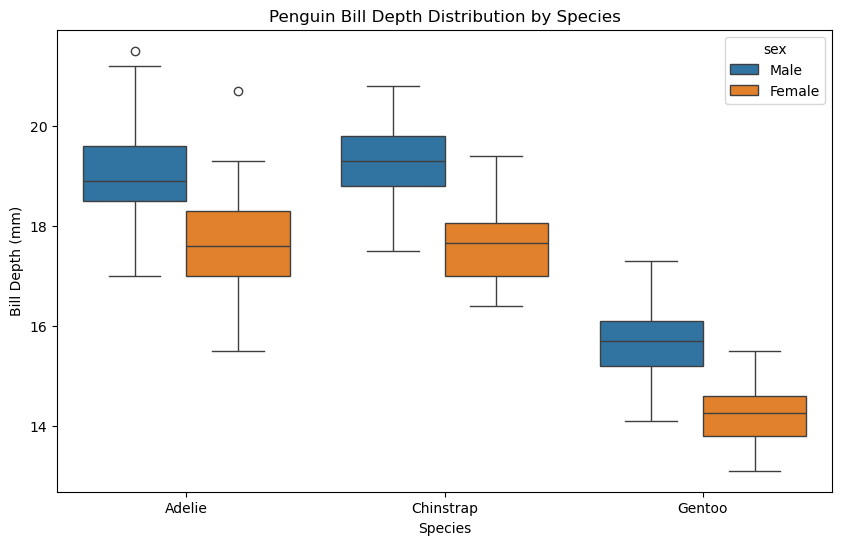

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=penguins_cleaned, x='species', y='body_mass_g', hue='sex')
plt.title("Penguin Body Mass Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.show

plt.figure(figsize=(10,6))
sns.boxplot(data=penguins_cleaned, x='species', y='flipper_length_mm', hue='sex')
plt.title("Penguin Flipper Length Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Flipper Length (mm)")
plt.show

plt.figure(figsize=(10,6))
sns.boxplot(data=penguins_cleaned, x='species', y='bill_length_mm', hue='sex')
plt.title("Penguin Bill Length Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Bill Length (mm)")
plt.show

plt.figure(figsize=(10,6))
sns.boxplot(data=penguins_cleaned, x='species', y='bill_depth_mm', hue='sex')
plt.title("Penguin Bill Depth Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Bill Depth (mm)")
plt.show

## Relationship chart

The following visualizations reveal:

* Body Mass to Flipper and Bill Length all have a positive correlation. But the degree of the correlation depends on species.
* Bill Length to Depth relationship is also positive, and is very similar across species.
  

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 1000x600 with 0 Axes>

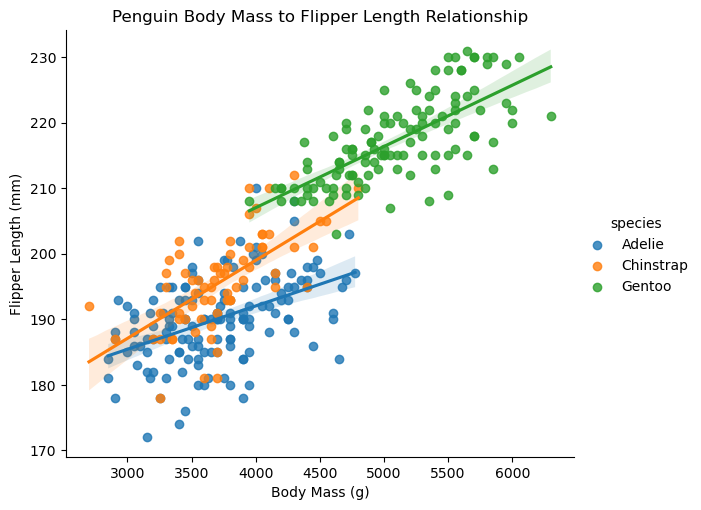

<Figure size 1000x600 with 0 Axes>

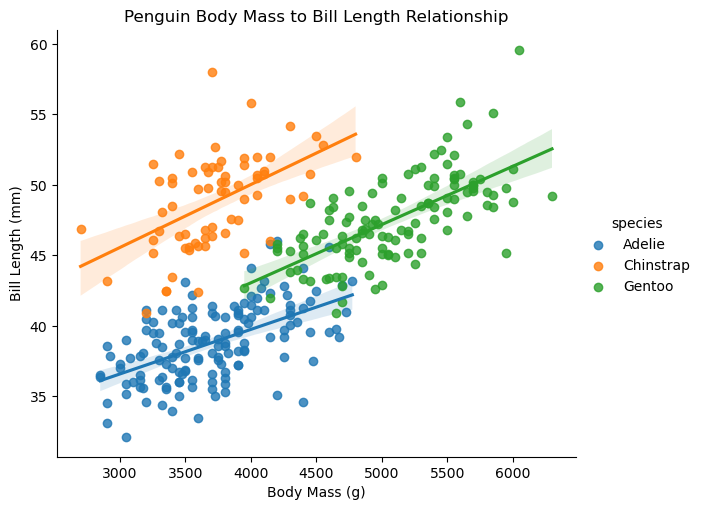

<Figure size 1000x600 with 0 Axes>

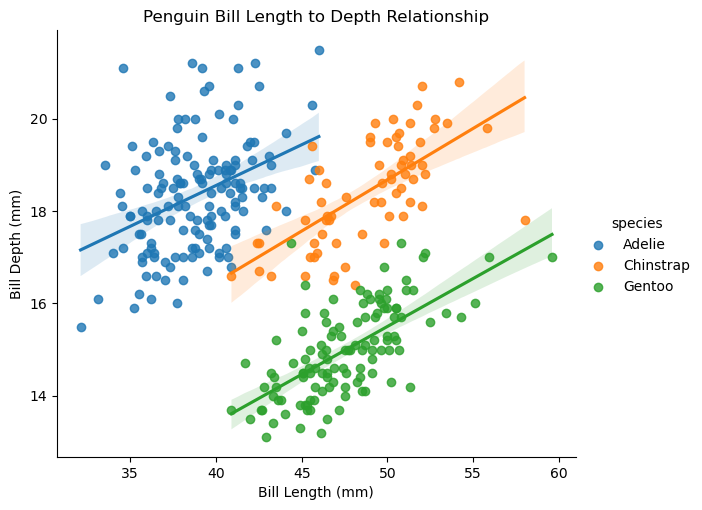

In [20]:
plt.figure(figsize=(10,6))
sns.lmplot(data=penguins_cleaned, x='body_mass_g', y='flipper_length_mm', hue='species', aspect=1.2)
plt.title("Penguin Body Mass to Flipper Length Relationship")
plt.xlabel("Body Mass (g)")
plt.ylabel("Flipper Length (mm)")
plt.show

plt.figure(figsize=(10,6))
sns.lmplot(data=penguins_cleaned, x='body_mass_g', y='bill_length_mm', hue='species', aspect=1.2)
plt.title("Penguin Body Mass to Bill Length Relationship")
plt.xlabel("Body Mass (g)")
plt.ylabel("Bill Length (mm)")
plt.show

plt.figure(figsize=(10,6))
sns.lmplot(data=penguins_cleaned, x='bill_length_mm', y='bill_depth_mm', hue='species', aspect=1.2)
plt.title("Penguin Bill Length to Depth Relationship")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show

## Further Visualization

* This visualization shows the previous distributions and relationships in a single plot but with less detail in individual plots. It allows for quickly cleaning insights about the general trends (such as Gentoo's size and flipper length being larger compared the other two species). 

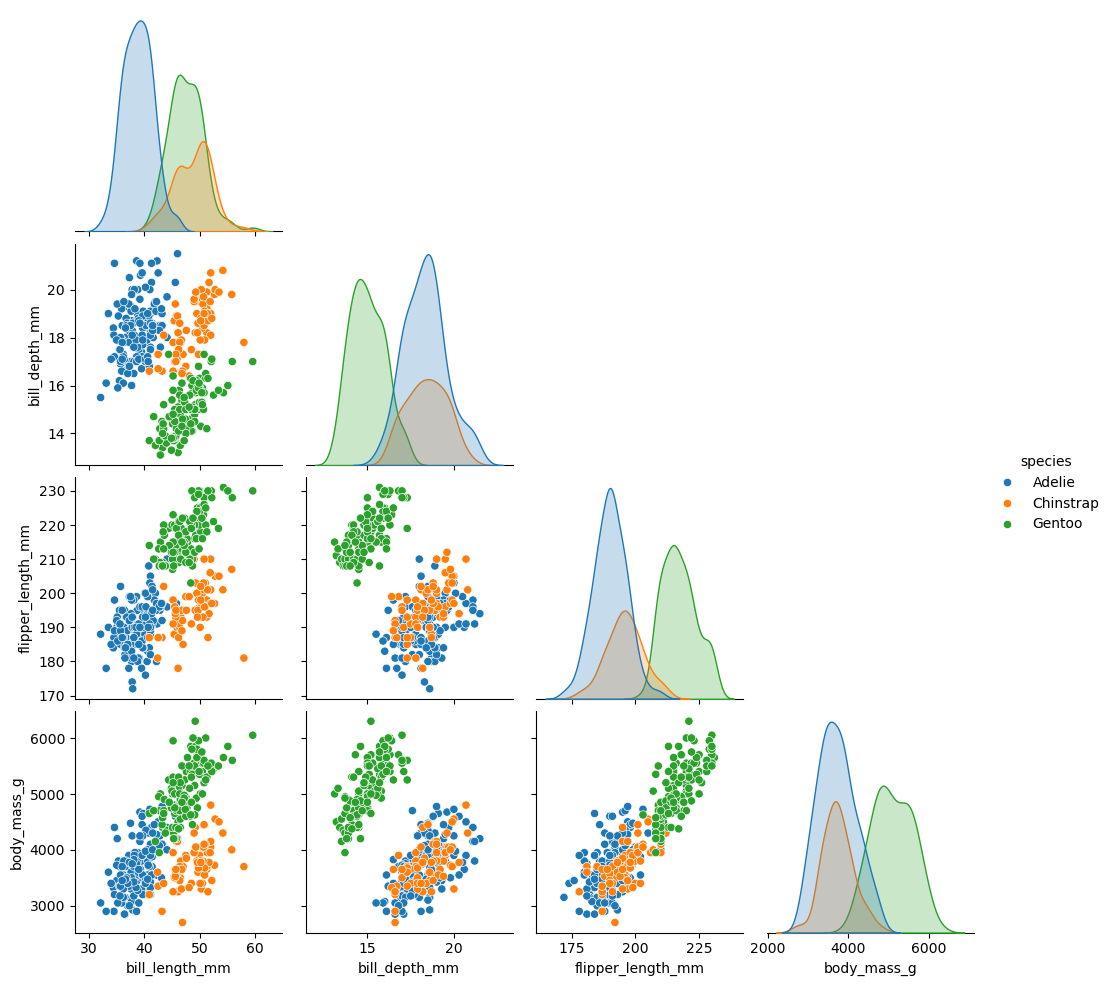

In [21]:
sns.pairplot(data=penguins_cleaned, hue='species', corner=True)

# Visualization Critique

(I did not see a provided visualization, so instead have created two which are poor.)

## The first visualization is one which shows the average body mass of the penguins by species. Numerically, these are:

* Adelie: 3607g; Chinstrap: 3733g; and Gentoo: 5092g

From the values, one can see that the Gentoo penguin is about 40% larger than the others. However, and what makes the visualization misleading, it appears that the Gentoo's size is double that of the other two. This is caused by having a y limit manually set to 2500g instead of starting at zero. This example is something that could be done on accident, especially if the bars are especially long and poorly differentiable at the tops. By setting a y limit, the difference can be exaggerated to proper effect. Here, rather than doing that, it instead would be intentionally misleading, trying to push a narrative that the size difference is more than it actually is. This is violating the Accuracy principle of visualizations by distorting the findings beyond what the should be. Redesigning here would be very simple, just leave the axis limit at 0, or lower it enough such that the difference is still accurate to the eye, but appropriately visible.

## The second visualization is one which shows the relationship between bill length and bill depth.

The problem with this visualization is that it fails to account for species differences and attempts to explain overall trends which are not accurate. When plotted together, it appears that with bill length increasing, bill depth decreases. However, that is untrue with proper context. When individual species are examined, such as in the visualization from part 2, bill length clearly has a positive correlation with bill depth. Missing that context makes the visualization misleading. As such, the principles violated here are accuracy and context, which go hand in hand in this situation. In this case, I would redesign by either separating into multiple plots, or having a hue/trendline for each species like I did in the previous part. 

<function matplotlib.pyplot.show(close=None, block=None)>

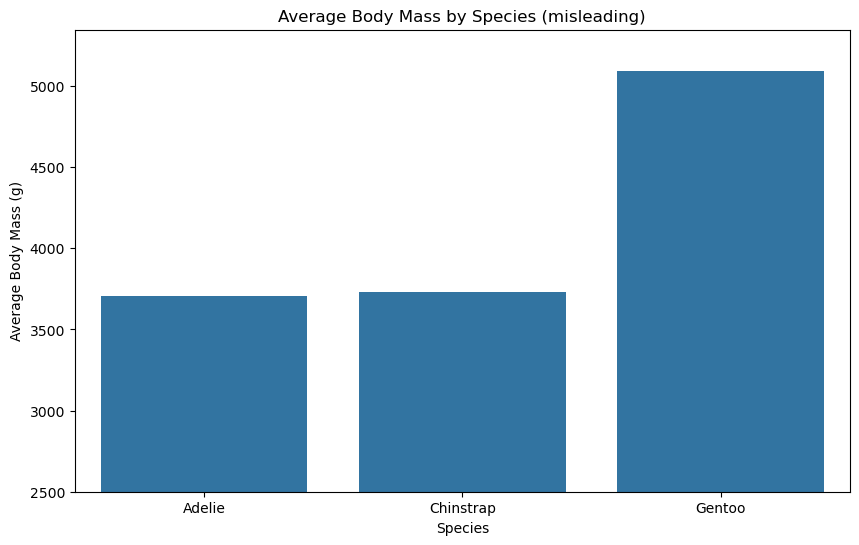

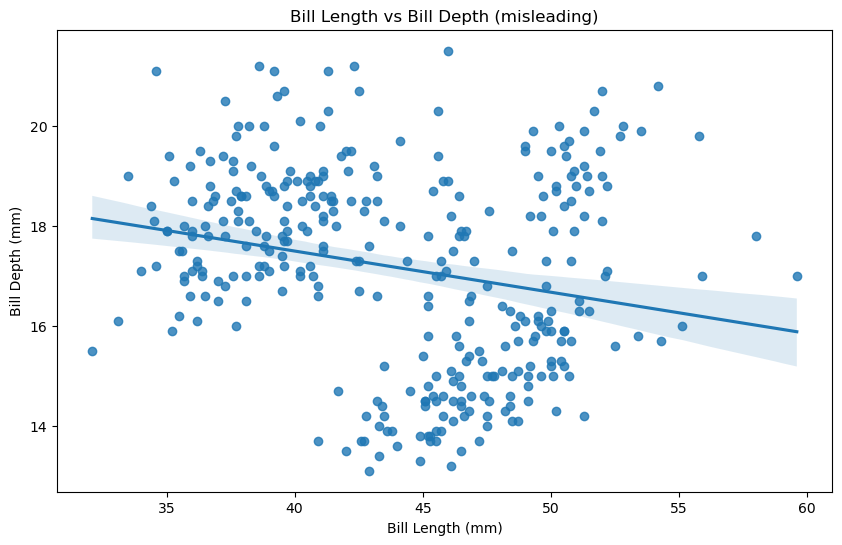

In [22]:
grouped_penguins = penguins_cleaned.groupby('species')['body_mass_g'].mean().reset_index()
grouped_penguins = grouped_penguins.sort_values(by='body_mass_g')
# print(grouped_penguins['body_mass_g'])

plt.figure(figsize=(10,6))
sns.barplot(data=grouped_penguins, y='body_mass_g', x='species')
plt.title("Average Body Mass by Species (misleading)")
plt.ylabel("Average Body Mass (g)")
plt.xlabel("Species")
plt.ylim(bottom=2500)
plt.show

plt.figure(figsize=(10,6))
sns.regplot(data=penguins_cleaned, x='bill_length_mm', y='bill_depth_mm')
plt.title("Bill Length vs Bill Depth (misleading)")
plt.ylabel("Bill Depth (mm)")
plt.xlabel("Bill Length (mm)")
plt.show

# Technical Report

## Overview
The dataset used is the palmerpenguins dataset, details found on the github repository https://github.com/allisonhorst/palmerpenguins/blob/main/README.md. The data was collected by a researcher at the Palmer Long-Term Ecological Research (LTER) study area. It contains information about 3 different penguin species across 3 different islands in the Palmer Archipelago in Antarctica. Each sample is a different penguin, with numerical data on their body mass, flipper length, bill length, and bill depth. In summary the data is as follows:

* Species: Adelie, Chinstrap, and Gentoo
* Islands: Biscoe, Dream, and Torgersen
* Physical anatomy: Body Mass (g), flipper length (mm), bill length (mm), and bill depth (mm)

This information is useful for numerous purposes, including the identification of individual penguins and the procedure for handling them, which may differ from species to species or island to island.

## Methods

I began by preparing the dataset by checking for null or nan values and cleaning accordingly. As only 11 of the 344 samples had missing values, I simply dropped those rows, rather than filling with a dummy variable or with a mean/median. I then generated some descriptions of the numerical and categorical variables, checking for things such as counts, averages, and standard deviations. From there, I approached the analysis by looking at simple comparisons between the different islands and species, then at correlations between the continuous variables. Count plots were valuable for looking at penguin counts across different categories. Boxplots were useful in comparing physiological differences between species. Finally, scatterplots with trendlines were helpful in visualizing regression trends in how numerical variables related to each other. 

## Results

Analysis suggests many insights, but for the sake of an identification task, I include only a few of the most important. First, the distribution of penguins across the 3 islands. As shown in Figure 1, Chinstrap penguins are found only on Dream island, Gentoo only on Biscoe, and Adelie on all three. 

### Figure 1. 

![Figure 1](island_count.png)

Next, the body mass comparisons show that Gentoo penguins are notably larger than the Adelie and Chinstrap species, even accounting for male-female differences. Adelie and Chinstrap species are similar. Also notable is the sexual dimorphism present within each species, where being larger body mass correlates to being male. Body mass visualization is shown in Figure 2. Similarly, shown in Figure 3, reveals much the same. Gentoo's tend to have longer flippers compared to the other two species, which have similar proportions to each other. 

### Figure 2. 

![Figure 2](body_masses.png)

### Figure 3.

![Figure 3](flipper_lengths.png)

Finally, bill length paints a different picture. As shown in Figure 4, the Adelie species has a notably shorter length bill than the Gentoo and Chinstrap. 

### Figure 4.

![Figure 4](bill_lengths.png)

## Discussion & Conclusions

The geographical and physiological differences analyzed directly reveal little about the ecological niches that each penguin species fills, but may serve to be useful to an expert in the sort of ecology that these animals live in. However, these characteristics can be useful predictors for the identification and handling of each species by an interested party or field researcher. When it comes to the preparation for handling, a field researcher should first consider which island is going to be visited. If the answer is Torgersen, they need only prepare for Adelie penguins. However, if it is either of the other islands, they will need to prepare for a mixture of two species. In the identification, one should first look at the size in both body mass and flipper length. Gentoo penguins should be notably larger than individuals from the other two species. In differentiating Adelie and Chinstrap, one could look at the bill length, where the Chinstrap species commonly has longer bills.

# Ethical Reflection

Data visualizations can unintentionally mislead audiences in numerous ways, some of which are harmless and make for a humorous memory, while others result in dangerous misinterpretations. Rather than specifically figuring out whether the situation requires that level of care, it is instead the responsibility of analysts to *always* ensure visualizations are *clear* and *accurate*. They can do so by ensuring the visualization is as clear as possible without missing information. Simplicity is an extremely important factor to weigh in a visualization. Too simple, and a visualization can lack important context or metrics by which a person gets the accurate picture of the data. Too complicated and the information may be obscured by other, unnecessary details. Often, if a plot is over-complicated, it can be made clearer by breaking it into several smaller plots and/or applying dimensionality reduction techniques (such as Principal Component Analysis). Clarity may also be an issue in the design of the visualization, including grid overlays, fonts, colors, and more. Here, an analyst must balance keeping the visual engaging with it being clear. In the pursuit of this clarity, they should also ensure it is clear to *everyone*, or in other words, is *accessible*. Colors are extremely important in this regard, and should be chosen intentionally. Visualizations should also be accurate. This is a culmination of proper data analysis. During exploratory data analysis (EDA), an analyst should strive to get a clear picture of all the different variables at hand and how they may interact. This allows for visuals which are to the point, and account for limitations and context. Without such a perspective, one runs the risk of overstating findings or leaving out crucial information that misleads audiences. A prime example of this is from part 3, with the bill length vs depth visualization, where adding the per-species context drastically changes how the information is interpreted.

# Challenge Questions

1. Which variable appears most influential in explaining the outcome?
   
* I would be remiss if I narrowed the findings down to a single variable. Because, no single variable seems to differentiate the species adequately. If only body mass was used, a person could confused the Adelie and Chinstrap. If only bill length was used, one could confuse the Chinstrap and Gentoo. Instead, I would say the two variables together effectively address the identification task.
  
3. Which visualization best communicates your strongest finding and why?
   
* The combined visualization of all distributions and relationships best communicates the information (shown below). Normally, I'm opposed to such visualizations, as they can feel cluttered and chaotic. However, with this data set, I believe it clearly shows each distribution, which is helpful for the identification task, as well as the variable relationships that would be useful to a more technically minded viewer that is curious about correlation.
  
4. What limitations exist in your analysis?
   
* I would say the biggest limitations in the analysis are limited ecological/environmental information. With only geographical and physical characteristics, I could only speculate on what the different physiological differences are, and how those characteristics play into their role in the ecosystem.
  
![Combined Plot](combined_plot.png)